In [ ]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPPy.utilities.metrics import PSNR, SSIM

from utils.data_utils import load_normalized_image


# Input
TEST_DIR = Path("../dataset_resized/test_resized")
TV_DIR = Path("../tv_reconstructions")

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

JSON_DIR = RESULTS_DIR / "json"
JSON_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLES_DIR = RESULTS_DIR / "example_comparison"
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

PATIENT = "C081"

# Configurazioni Limited-Angle CT
N_ANGLES_CONFIGS = [90, 45, 30, 15]

ANGLE_INTERVALS = {
    90: "[-45°, 45°]",
    45: "[-45°, 45°]",
    30: "(-30°, 30°)",
    15: "(-30°, 30°)",
}

GT_DIR = TEST_DIR / PATIENT
TV_TEST_DIR = TV_DIR / "test"

In [3]:
#Controllo corrispondenza tra ricostruzioni TV e ground truth del paziente c81

gt_paths = sorted(
    GT_DIR.glob("*.png"),
    key=lambda p: int(p.stem)
)

print(f"Ground truth c81: {len(gt_paths)} slice")


for n_angles in N_ANGLES_CONFIGS:

    tv_config_dir = TV_TEST_DIR / str(n_angles) / PATIENT

    tv_paths = sorted(
        tv_config_dir.glob("*.npy"),
        key=lambda p: int(p.stem)
    )

    gt_stems = {p.stem for p in gt_paths}
    tv_stems = {p.stem for p in tv_paths}

    missing_gt = tv_stems - gt_stems
    missing_tv = gt_stems - tv_stems

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Ricostruzioni TV: {len(tv_paths)}")
    print(f"TV senza ground truth: {len(missing_gt)}")
    print(f"Ground truth senza TV: {len(missing_tv)}")

Ground truth c81: 327 slice

90 angoli [-45°, 45°]
Ricostruzioni TV: 327
TV senza ground truth: 0
Ground truth senza TV: 0

45 angoli [-45°, 45°]
Ricostruzioni TV: 327
TV senza ground truth: 0
Ground truth senza TV: 0

30 angoli (-30°, 30°)
Ricostruzioni TV: 327
TV senza ground truth: 0
Ground truth senza TV: 0

15 angoli (-30°, 30°)
Ricostruzioni TV: 327
TV senza ground truth: 0
Ground truth senza TV: 0


In [4]:
#Controllo dtype e range delle ricostruzioni TV sul test set

for n_angles in N_ANGLES_CONFIGS:

    tv_paths = sorted(
        (TV_TEST_DIR / str(n_angles) / PATIENT).glob("*.npy"),
        key=lambda p: int(p.stem)
    )

    global_min = np.inf
    global_max = -np.inf

    pixels_below_0 = 0
    pixels_above_1 = 0
    total_pixels = 0

    for tv_path in tv_paths:

        image = np.load(tv_path)

        global_min = min(global_min, image.min())
        global_max = max(global_max, image.max())

        pixels_below_0 += np.sum(image < 0)
        pixels_above_1 += np.sum(image > 1)
        total_pixels += image.size

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Range: [{global_min:.4f}, {global_max:.4f}]")
    print(f"Pixel sotto 0: {100 * pixels_below_0 / total_pixels:.4f}%")
    print(f"Pixel sopra 1: {100 * pixels_above_1 / total_pixels:.4f}%")


90 angoli [-45°, 45°]
Range: [0.0000, 1.3639]
Pixel sotto 0: 0.0000%
Pixel sopra 1: 0.0012%

45 angoli [-45°, 45°]
Range: [0.0000, 1.4939]
Pixel sotto 0: 0.0000%
Pixel sopra 1: 0.0014%

30 angoli (-30°, 30°)
Range: [0.0000, 1.5463]
Pixel sotto 0: 0.0000%
Pixel sopra 1: 0.0016%

15 angoli (-30°, 30°)
Range: [0.0000, 1.5491]
Pixel sotto 0: 0.0000%
Pixel sopra 1: 0.0015%


In [5]:
#Caricamento delle ricostruzioni TV con clipping nel range [0,1]

def load_tv_reconstruction(path: Path):
    image = np.load(path).astype(np.float32)
    return np.clip(image, 0.0, 1.0)

In [6]:
#Calcolo PSNR e SSIM tra ricostruzioni TV e ground truth sul test set

results = {}


for n_angles in N_ANGLES_CONFIGS:

    tv_paths = sorted(
        (TV_TEST_DIR / str(n_angles) / PATIENT).glob("*.npy"),
        key=lambda p: int(p.stem)
    )

    psnr_values = []
    ssim_values = []
    slice_names = []

    for tv_path in tqdm(tv_paths, desc=f"Metriche TV [{n_angles} angoli]"):

        # Ground truth corrispondente alla stessa slice
        gt_path = GT_DIR / f"{tv_path.stem}.png"

        if not gt_path.exists():
            print(f"Ground truth non trovata per {tv_path.name}")
            continue

        # Ground truth normalizzata in [0,1]
        gt = load_normalized_image(gt_path)

        # Ricostruzione TV con clipping in [0,1]
        tv = load_tv_reconstruction(tv_path)

        if gt.shape != tv.shape:
            print(f"Shape diverse per slice {tv_path.stem}: GT={gt.shape}, TV={tv.shape}")
            continue

        # Tensor nel formato (batch, channel, height, width)
        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
        x_tv = torch.from_numpy(tv).float().unsqueeze(0).unsqueeze(0)

        psnr_value = float(PSNR(x_tv, x_true))
        ssim_value = float(SSIM(x_tv, x_true))

        psnr_values.append(psnr_value)
        ssim_values.append(ssim_value)
        slice_names.append(tv_path.stem)

    results[n_angles] = {
        "slice": slice_names,
        "PSNR": psnr_values,
        "SSIM": ssim_values,
    }

Metriche TV [15 angoli]: 100%|██████████| 327/327 [00:03<00:00, 85.99it/s] 


In [7]:
#Risultati medi di PSNR e SSIM per ciascuna configurazione angolare

print("RISULTATI TV SUL TEST SET - PAZIENTE c81")

for n_angles in N_ANGLES_CONFIGS:

    psnr_values = np.array(results[n_angles]["PSNR"])
    ssim_values = np.array(results[n_angles]["SSIM"])

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Numero slice: {len(psnr_values)}")
    print(f"PSNR medio: {psnr_values.mean():.2f} ± {psnr_values.std():.2f} dB")
    print(f"SSIM medio: {ssim_values.mean():.4f} ± {ssim_values.std():.4f}")

RISULTATI TV SUL TEST SET - PAZIENTE c81

90 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 23.83 ± 2.12 dB
SSIM medio: 0.7257 ± 0.0502

45 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 23.79 ± 2.14 dB
SSIM medio: 0.7221 ± 0.0505

30 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 21.75 ± 2.35 dB
SSIM medio: 0.6426 ± 0.0605

15 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 21.51 ± 2.37 dB
SSIM medio: 0.6231 ± 0.0644


In [ ]:
import json

summary_out = {
    str(n_angles): {
        "psnr_mean": float(np.mean(results[n_angles]["PSNR"])),
        "psnr_std": float(np.std(results[n_angles]["PSNR"])),
        "ssim_mean": float(np.mean(results[n_angles]["SSIM"])),
        "ssim_std": float(np.std(results[n_angles]["SSIM"])),
        "n_slices": len(results[n_angles]["PSNR"]),
    }
    for n_angles in N_ANGLES_CONFIGS
}

out_path = JSON_DIR / "tv_test_metrics.json"
with open(out_path, "w") as f:
    json.dump(summary_out, f, indent=2)

print(f"Riepilogo salvato in: {out_path}")

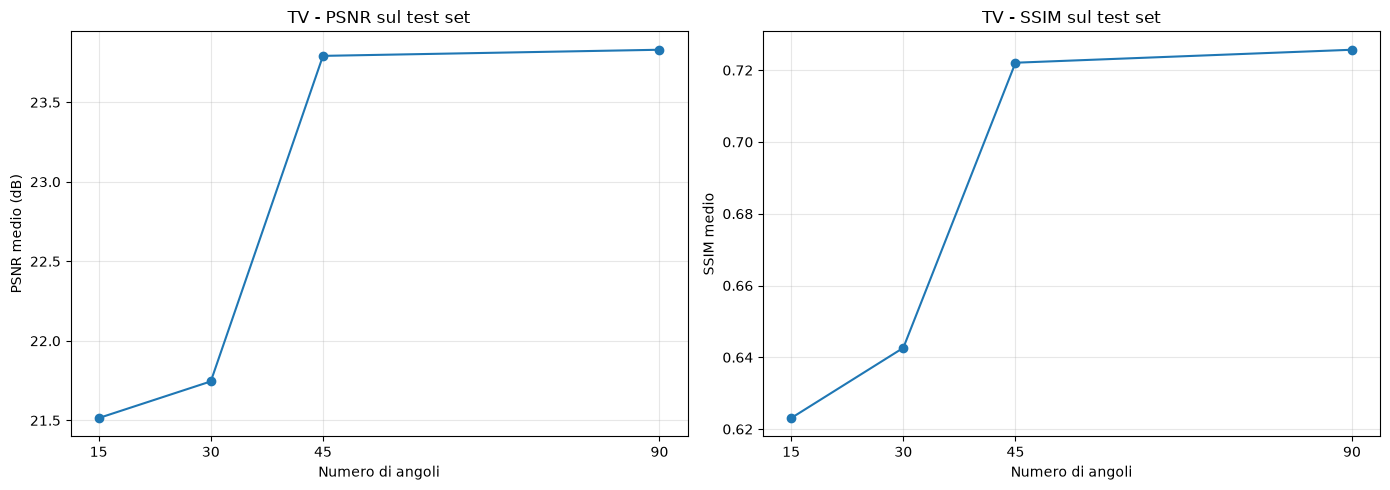

In [8]:
#Grafico PSNR e SSIM medi per configurazione angolare

psnr_means = [
    np.mean(results[n_angles]["PSNR"])
    for n_angles in N_ANGLES_CONFIGS
]

ssim_means = [
    np.mean(results[n_angles]["SSIM"])
    for n_angles in N_ANGLES_CONFIGS
]


fig, axs = plt.subplots(1, 2, figsize=(14, 5))


axs[0].plot(
    N_ANGLES_CONFIGS,
    psnr_means,
    marker="o"
)

axs[0].set_xlabel("Numero di angoli")
axs[0].set_ylabel("PSNR medio (dB)")
axs[0].set_title("TV - PSNR sul test set")
axs[0].set_xticks(N_ANGLES_CONFIGS)
axs[0].grid(alpha=0.3)


axs[1].plot(
    N_ANGLES_CONFIGS,
    ssim_means,
    marker="o"
)

axs[1].set_xlabel("Numero di angoli")
axs[1].set_ylabel("SSIM medio")
axs[1].set_title("TV - SSIM sul test set")
axs[1].set_xticks(N_ANGLES_CONFIGS)
axs[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

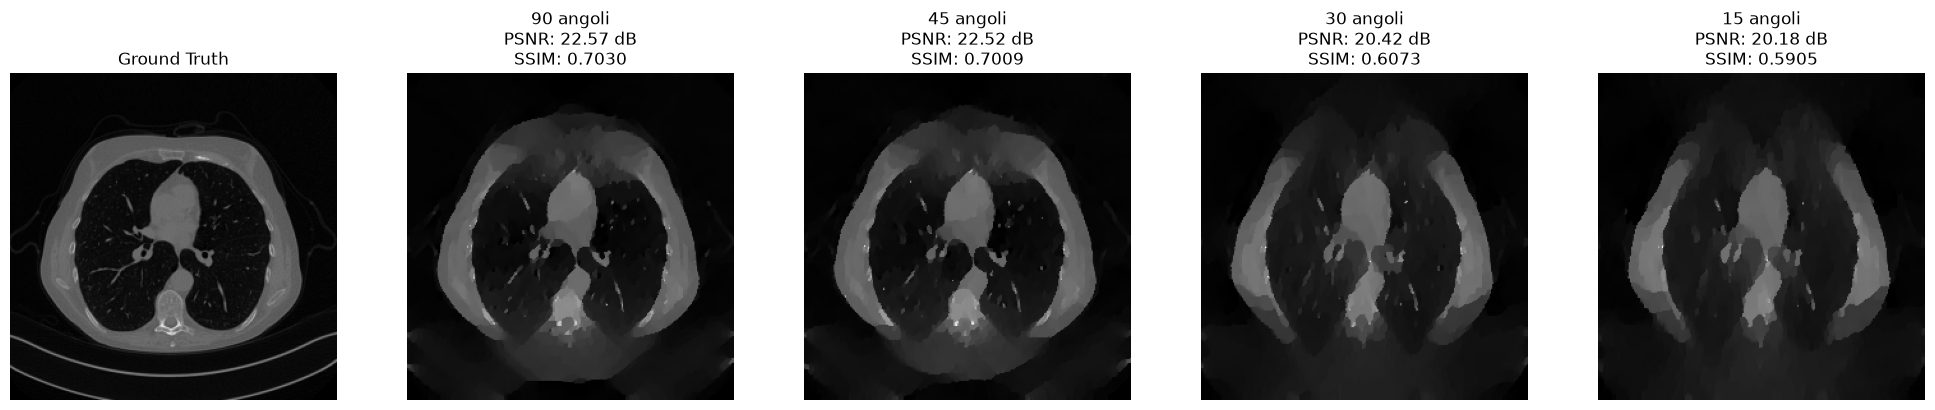

In [ ]:
#Confronto visivo tra ground truth e ricostruzioni TV

# Slice centrale del paziente c81
example_gt_path = gt_paths[len(gt_paths) // 2]
slice_name = example_gt_path.stem

gt = load_normalized_image(example_gt_path)


fig, axs = plt.subplots(1, 5, figsize=(20, 4))


axs[0].imshow(gt, cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Ground Truth")
axs[0].axis("off")


for ax, n_angles in zip(axs[1:], N_ANGLES_CONFIGS):

    tv_path = (
        TV_TEST_DIR
        / str(n_angles)
        / PATIENT
        / f"{slice_name}.npy"
    )

    tv = load_tv_reconstruction(tv_path)

    x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
    x_tv = torch.from_numpy(tv).float().unsqueeze(0).unsqueeze(0)

    psnr_value = float(PSNR(x_tv, x_true))
    ssim_value = float(SSIM(x_tv, x_true))

    ax.imshow(tv, cmap="gray", vmin=0, vmax=1)

    ax.set_title(
        f"{n_angles} angoli\n"
        f"PSNR: {psnr_value:.2f} dB\n"
        f"SSIM: {ssim_value:.4f}"
    )

    ax.axis("off")


plt.tight_layout()
plt.savefig(EXAMPLES_DIR / "demo_tv_vs_gt.png", dpi=150)
plt.show()